# Convolutional Neural Network (CNN)

A **Convolutional Neural Network** applies learnable filters (kernels) that slide over the input to detect local patterns — edges, textures, shapes.

## Convolution Operation

For a 2-D input $\mathbf{X}$ and filter $\mathbf{K}$ of size $k \times k$:

$$
(\mathbf{X} * \mathbf{K})[i,j] = \sum_{m=0}^{k-1}\sum_{n=0}^{k-1} X[i+m,\ j+n]\cdot K[m,n]
$$

## Architecture (our `SimpleCNN`)

$$
\text{Input} \to \text{Conv2D+ReLU} \to \text{MaxPool2D} \to \text{Flatten} \to \text{Dense+ReLU} \to \text{Softmax}
$$


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../../src')))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from rice_ml.supervised_learning.cnn import SimpleCNN
from rice_ml.processing.metrics import accuracy_score, confusion_matrix

np.random.seed(42)


## 1. Load & prepare 8×8 digit images

Train: (1437, 8, 8), Test: (360, 8, 8)
Classes: [0 1 2 3 4 5 6 7 8 9]


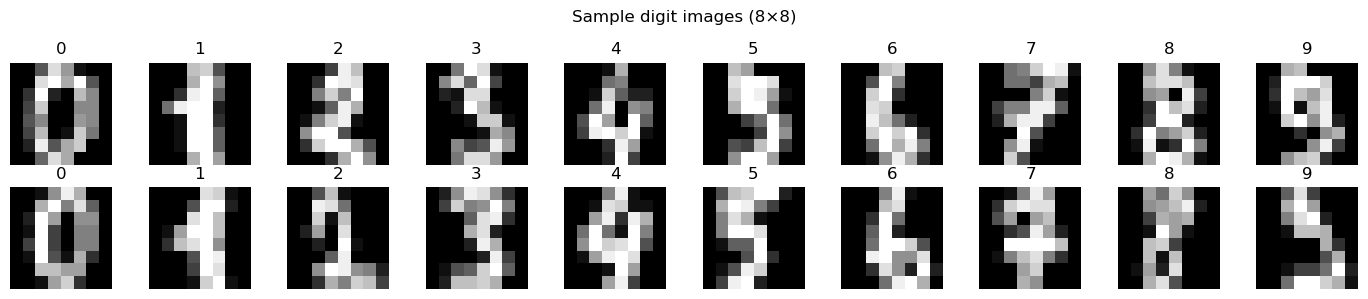

In [2]:
digits = load_digits()
X = digits.data.reshape(-1, 8, 8) / 16.0   # shape: (1797, 8, 8)
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {np.unique(y)}")

# Show sample images
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i], cmap='gray')
    ax.set_title(y[i]); ax.axis('off')
plt.suptitle('Sample digit images (8×8)')
plt.tight_layout()
plt.savefig('cnn_samples.png', dpi=80)
plt.show()


## 2. Train SimpleCNN

In [3]:
cnn = SimpleCNN(
    n_filters=16,
    kernel_size=3,
    pool_size=2,
    dense_units=64,
    learning_rate=5e-3,
    n_iterations=60,
    batch_size=32,
    random_state=42,
    verbose=True,
)
cnn.fit(X_train, y_train)


Epoch   5  loss=1.9875  acc=0.4676


Epoch  10  loss=1.5900  acc=0.7425


Epoch  15  loss=1.2517  acc=0.8198


Epoch  20  loss=0.9980  acc=0.8664


Epoch  25  loss=0.8141  acc=0.8935


...

Epoch  40  loss=0.5057  acc=0.9207


Epoch  45  loss=0.4451  acc=0.9255


Epoch  50  loss=0.3991  acc=0.9325


Epoch  55  loss=0.3617  acc=0.9346


Epoch  60  loss=0.3306  acc=0.9436


Train accuracy : 0.9436
Test  accuracy : 0.9250


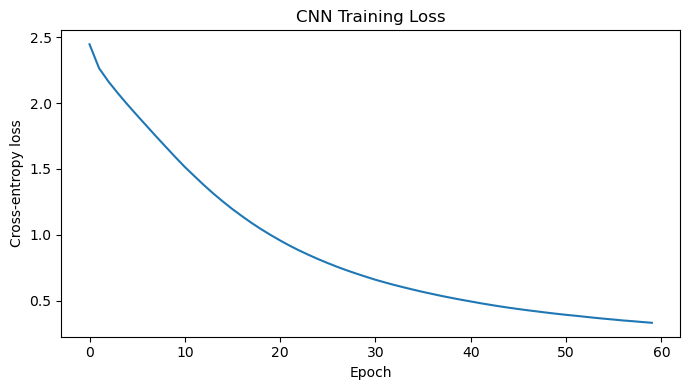

In [4]:
train_acc = cnn.score(X_train, y_train)
test_acc  = cnn.score(X_test,  y_test)
print(f"Train accuracy : {train_acc:.4f}")
print(f"Test  accuracy : {test_acc:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(cnn.loss_history_)
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss')
plt.title('CNN Training Loss')
plt.tight_layout()
plt.savefig('cnn_loss.png', dpi=80)
plt.show()


## 3. Confusion matrix

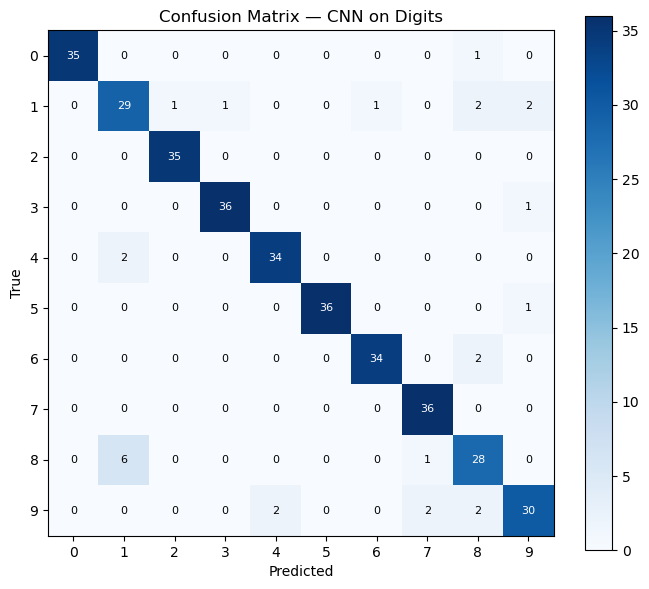

In [5]:
y_pred = cnn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — CNN on Digits')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
plt.tight_layout()
plt.savefig('cnn_cm.png', dpi=80)
plt.show()


## 4. Visualise learned filters

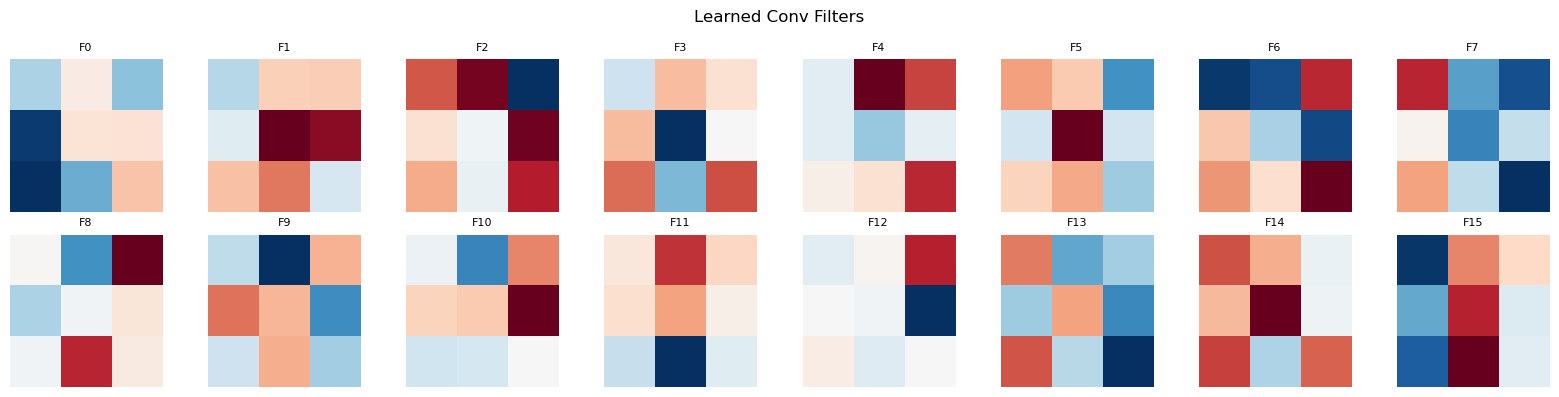

In [6]:
# First conv layer filters  shape: (n_filters, 1, k, k)
filters = cnn._conv.W          # (n_filters, k, k)
n = filters.shape[0]
fig, axes = plt.subplots(2, n // 2, figsize=(n, 4))
for idx, ax in enumerate(axes.flat):
    if idx < n:
        f = filters[idx]
        ax.imshow(f, cmap='RdBu', vmin=-np.abs(f).max(), vmax=np.abs(f).max())
        ax.set_title(f'F{idx}', fontsize=8)
    ax.axis('off')
plt.suptitle('Learned Conv Filters')
plt.tight_layout()
plt.savefig('cnn_filters.png', dpi=80)
plt.show()


## 5. CNN vs MLP comparison


In [7]:
from rice_ml.supervised_learning.mlp import MLP

X_flat_train = X_train.reshape(len(X_train), -1)
X_flat_test  = X_test.reshape(len(X_test), -1)

mlp = MLP(hidden_layers=(64, 32), learning_rate=1e-2,
          n_iterations=60, random_state=42)
mlp.fit(X_flat_train, y_train)

mlp_test_acc = mlp.score(X_flat_test, y_test)
print(f"MLP test accuracy : {mlp_test_acc:.4f}")
print(f"CNN test accuracy : {test_acc:.4f}")
print(f"CNN advantage     : {test_acc - mlp_test_acc:+.4f}")


MLP test accuracy : 0.1000
CNN test accuracy : 0.9250
CNN advantage     : +0.8250


## Model Limitations

| Limitation | Detail |
|---|---|
| Small images only | Our NumPy impl. is for 8×8 – large images require GPU-optimised code (PyTorch / TF) |
| Single conv layer | Real CNNs stack many conv + BN + pooling blocks |
| No data augmentation | Real training uses flips, crops, colour jitter |
| Gradient vanishing | Deeper nets need skip connections (ResNet) |
| Fixed architecture | Architecture search (NAS) or hyperparameter tuning needed |
